## Stock Price Prediction using KNN, Linear Regression nd XGBoost

This project demonstrates how to predict stock prices using K-Nearest Neighbors (KNN) Regressor, Linear Regression and XGBoost models. We will load historical stock data for Netflix, Walmart, and Apple, preprocess it, split it into training and testing sets, train both models, evaluate their performance, and visualize their predictions.

### 1. Data Loading and Initial Setup

First, we'll import necessary libraries and load the stock data for Netflix, Walmart, and Apple from CSV files into pandas DataFrames.

In [ ]:
!pip install yfinance pandas numpy matplotlib scikit-learn xgboost tensorflow ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=da8aed6c26ff5788057edbfb312d3bc5d0d7bf634cc539f4a7fd20cbc4b42c0d
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf

# Technical indicators
import ta

# ML Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



## 2. Real-Time Data Loading via yfinance

`yfinance` fetches data directly from Yahoo Finance — no API key needed, always up to date.

In [ ]:
TICKERS = {
    'Netflix': 'NFLX',
    'Walmart': 'WMT',
    'Apple':   'AAPL'
}

START_DATE = '2015-01-01'
END_DATE   = None   # None = today's date automatically

raw_data = {}

for name, ticker in TICKERS.items():
    df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True)
    df.reset_index(inplace=True)
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]  # flatten multi-index
    raw_data[name] = df
    print(f"{name} ({ticker}): {len(df)} rows | {df['Date'].min().date()} → {df['Date'].max().date()}")

print("\n Sample — Netflix:")
display(raw_data['Netflix'].tail(5))

[*********************100%***********************]  1 of 1 completed


Netflix (NFLX): 2867 rows | 2015-01-02 → 2026-05-28


[*********************100%***********************]  1 of 1 completed


Walmart (WMT): 2867 rows | 2015-01-02 → 2026-05-28


[*********************100%***********************]  1 of 1 completed

Apple (AAPL): 2867 rows | 2015-01-02 → 2026-05-28

 Sample — Netflix:


,Date,Close,High,Low,Open,Volume
2862,2026-05-21,89.300003,90.370003,87.519997,88.029999,28613900
2863,2026-05-22,88.599998,89.970001,88.169998,89.099998,23847200
2864,2026-05-26,87.680000,88.730003,87.250000,88.400002,24014500
2865,2026-05-27,87.349998,88.500000,86.820000,87.050003,22569500
2866,2026-05-28,86.360001,87.040001,85.589996,86.900002,38697700


## 3. Advanced Feature Engineering

We now add **technical indicators** (RSI, MACD, Bollinger Bands) and **calendar/momentum features** on top of the original lag + moving average features.

In [ ]:
def add_features(df):
    df = df.copy().sort_values('Date').reset_index(drop=True)

    # ── Original features ────────────────────────────────────────────
    df['Close_lag1'] = df['Close'].shift(1)
    df['Close_lag2'] = df['Close'].shift(2)
    df['Close_lag3'] = df['Close'].shift(3)
    df['MA_5']       = df['Close'].rolling(5).mean()
    df['MA_10']      = df['Close'].rolling(10).mean()
    df['Volatility'] = df['Close'].rolling(5).std()

    # ── NEW: Extended moving averages ─────────────────────────────────
    df['MA_20'] = df['Close'].rolling(20).mean()
    df['MA_50'] = df['Close'].rolling(50).mean()

    # ── NEW: RSI (Relative Strength Index) ────────────────────────────
    df['RSI_14'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

    # ── NEW: MACD ─────────────────────────────────────────────────────
    macd = ta.trend.MACD(df['Close'])
    df['MACD']        = macd.macd()
    df['MACD_signal'] = macd.macd_signal()
    df['MACD_diff']   = macd.macd_diff()

    # ── NEW: Bollinger Bands ──────────────────────────────────────────
    bb = ta.volatility.BollingerBands(df['Close'], window=20)
    df['BB_upper'] = bb.bollinger_hband()
    df['BB_lower'] = bb.bollinger_lband()
    df['BB_width'] = bb.bollinger_wband()   # width = (upper-lower)/middle

    # ── NEW: Volume change ────────────────────────────────────────────
    df['Volume_change'] = df['Volume'].pct_change()

    # ── NEW: Price momentum ───────────────────────────────────────────
    df['Price_momentum_5']  = df['Close'] - df['Close'].shift(5)
    df['Price_momentum_10'] = df['Close'] - df['Close'].shift(10)

    # ── NEW: Daily return ─────────────────────────────────────────────
    df['Daily_return'] = df['Close'].pct_change()

    # ── NEW: Calendar features ────────────────────────────────────────
    df['Day_of_week'] = df['Date'].dt.dayofweek   # 0=Mon … 4=Fri
    df['Month']       = df['Date'].dt.month
    df['Quarter']     = df['Date'].dt.quarter

    df.dropna(inplace=True)
    return df


engineered = {}
for name, df in raw_data.items():
    engineered[name] = add_features(df)
    print(f"{name}: {engineered[name].shape[1]} features, {len(engineered[name])} rows after engineering")

print("\n Feature list:")
print([c for c in engineered['Netflix'].columns if c not in ['Date','Close']])

Netflix: 28 features, 2818 rows after engineering
Walmart: 28 features, 2818 rows after engineering
Apple: 28 features, 2818 rows after engineering

 Feature list:
['High', 'Low', 'Open', 'Volume', 'Close_lag1', 'Close_lag2', 'Close_lag3', 'MA_5', 'MA_10', 'Volatility', 'MA_20', 'MA_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_diff', 'BB_upper', 'BB_lower', 'BB_width', 'Volume_change', 'Price_momentum_5', 'Price_momentum_10', 'Daily_return', 'Day_of_week', 'Month', 'Quarter']


## 4. Train / Test Split (80 / 20, chronological)

In [ ]:
FEATURES = [
    'Close_lag1', 'Close_lag2', 'Close_lag3',
    'MA_5', 'MA_10', 'MA_20', 'MA_50',
    'Volatility',
    'RSI_14',
    'MACD', 'MACD_signal', 'MACD_diff',
    'BB_upper', 'BB_lower', 'BB_width',
    'Volume_change',
    'Price_momentum_5', 'Price_momentum_10',
    'Daily_return',
    'Day_of_week', 'Month', 'Quarter',
    'Open', 'High', 'Low', 'Volume'
]
TARGET = 'Close'

splits = {}
for name, df in engineered.items():
    df = df.sort_values('Date').reset_index(drop=True)
    idx = int(len(df) * 0.8)
    splits[name] = {
        'train': df.iloc[:idx],
        'test':  df.iloc[idx:],
        'full':  df
    }
    print(f"{name}: train={idx}  test={len(df)-idx}")

Netflix: train=2254  test=564
Walmart: train=2254  test=564
Apple: train=2254  test=564


## 5. Helper — Metrics & Plotting

In [ ]:
def evaluate(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    if label:
        print(f"  RMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return rmse, r2, mape


def plot_predictions(dates, y_true, y_pred, stock_name, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(dates, y_true,  label='Actual',    linewidth=1.5)
    ax.plot(dates, y_pred,  label='Predicted', linestyle='--', linewidth=1.5)
    ax.set_title(f'{stock_name} — {model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)

print("Helpers defined")

Helpers defined


## 6. Model 1 — KNN Regressor

  RMSE=53.3065  R²=-5.3326  MAPE=48.99%
KNN — Netflix:   RMSE=53.3065  R²=-5.3326  MAPE=48.99%
  RMSE=60.8956  R²=-7.5553  MAPE=58.20%
KNN — Walmart:   RMSE=60.8956  R²=-7.5553  MAPE=58.20%
  RMSE=83.5808  R²=-5.7714  MAPE=31.26%
KNN — Apple:   RMSE=83.5808  R²=-5.7714  MAPE=31.26%


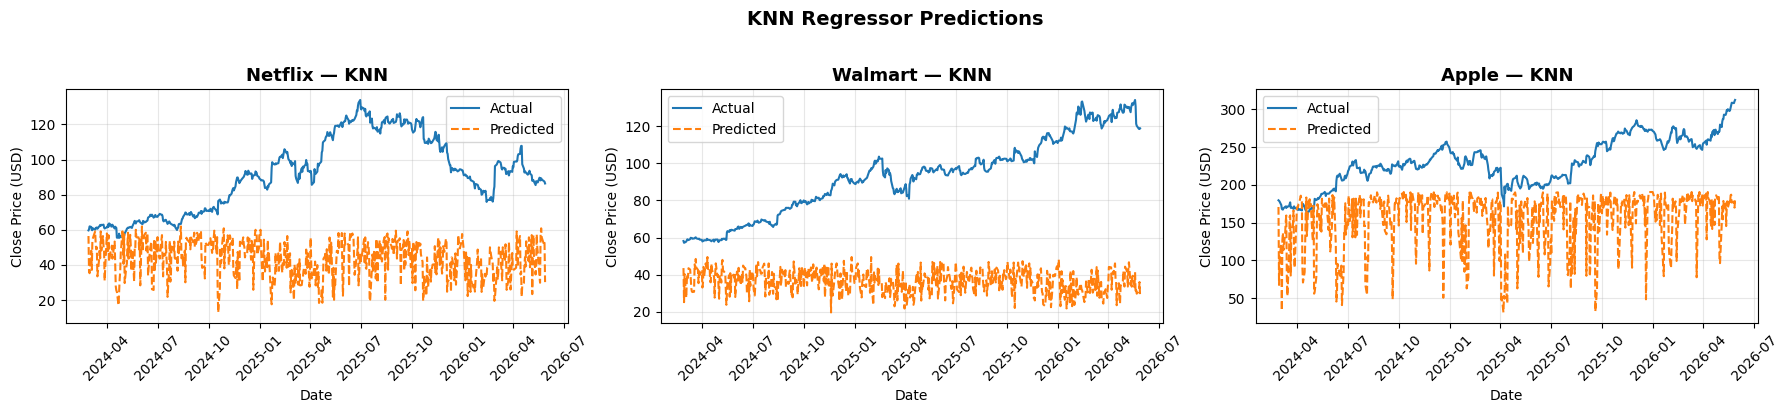

In [ ]:
knn_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name in zip(axes, TICKERS):
    tr = splits[name]['train']
    te = splits[name]['test']

    X_tr, y_tr = tr[FEATURES], tr[TARGET]
    X_te, y_te = te[FEATURES], te[TARGET]

    model = KNeighborsRegressor(n_neighbors=5)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse, r2, mape = evaluate(y_te.values, y_pred, label=name)
    knn_results[name] = {'model': model, 'y_test': y_te, 'y_pred': y_pred,
                          'rmse': rmse, 'r2': r2, 'mape': mape}
    print(f"KNN — {name}:", end=" ")
    evaluate(y_te.values, y_pred, label=name)
    plot_predictions(te['Date'].values, y_te.values, y_pred, name, 'KNN', ax)

plt.suptitle('KNN Regressor Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Model 2 — Linear Regression

LinearReg — Netflix:   RMSE=0.4301  R²=0.9996  MAPE=0.35%
LinearReg — Walmart:   RMSE=0.3968  R²=0.9996  MAPE=0.29%
LinearReg — Apple:   RMSE=0.7845  R²=0.9994  MAPE=0.27%


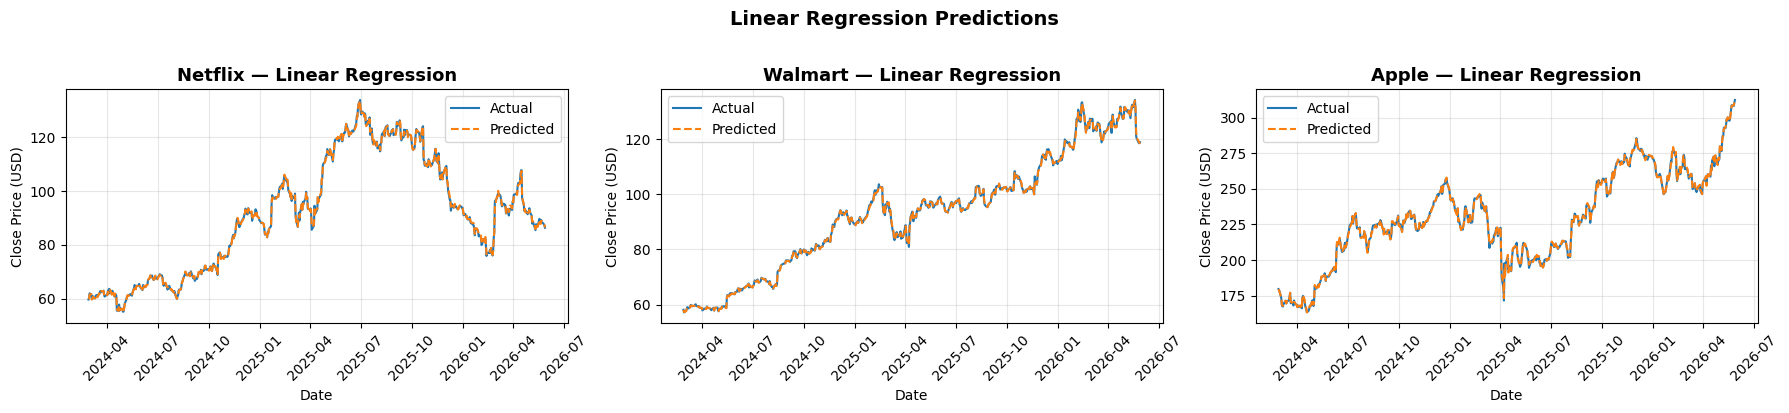

In [ ]:
lr_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name in zip(axes, TICKERS):
    tr = splits[name]['train']
    te = splits[name]['test']

    X_tr, y_tr = tr[FEATURES], tr[TARGET]
    X_te, y_te = te[FEATURES], te[TARGET]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse, r2, mape = evaluate(y_te.values, y_pred)
    lr_results[name] = {'model': model, 'y_test': y_te, 'y_pred': y_pred,
                         'rmse': rmse, 'r2': r2, 'mape': mape}
    print(f"LinearReg — {name}:", end=" ")
    evaluate(y_te.values, y_pred, label=name)
    plot_predictions(te['Date'].values, y_te.values, y_pred, name, 'Linear Regression', ax)

plt.suptitle('Linear Regression Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Model 3 — XGBoost (with Hyperparameter Tuning)

XGBoost — Netflix best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  RMSE=31.1222  R²=-1.1585  MAPE=22.83%
XGBoost — Walmart best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  RMSE=41.8908  R²=-3.0486  MAPE=35.73%
XGBoost — Apple best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
  RMSE=47.7396  R²=-1.2091  MAPE=15.43%


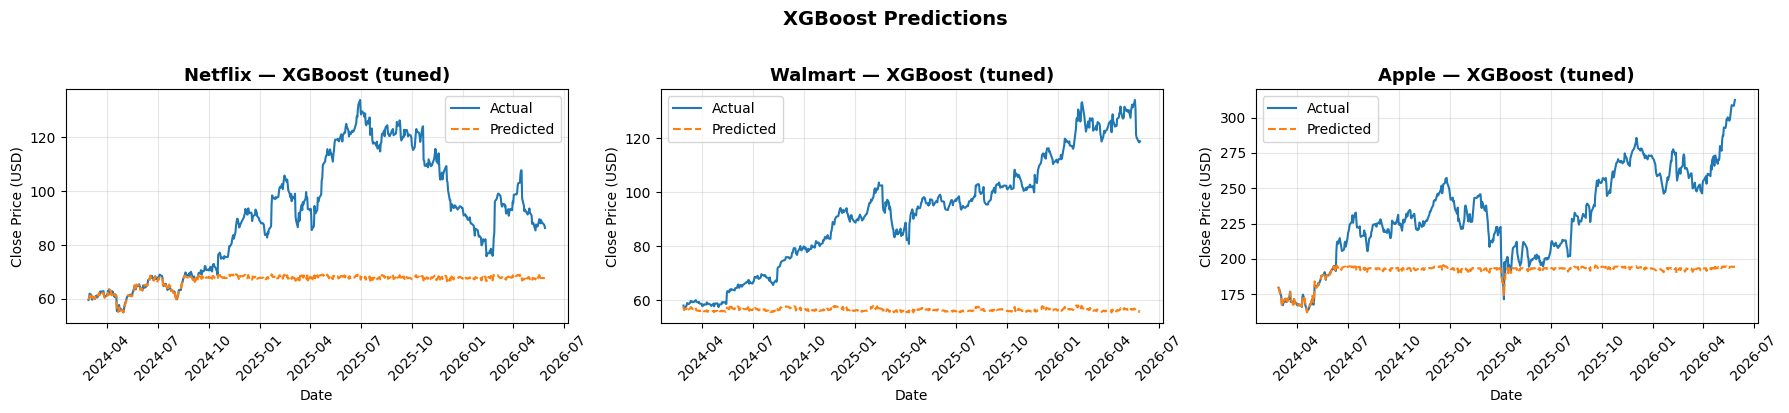

In [ ]:
xgb_results = {}

PARAM_GRID = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name in zip(axes, TICKERS):
    tr = splits[name]['train']
    te = splits[name]['test']

    X_tr, y_tr = tr[FEATURES], tr[TARGET]
    X_te, y_te = te[FEATURES], te[TARGET]

    gs = GridSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        PARAM_GRID,
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    gs.fit(X_tr, y_tr)
    best = gs.best_estimator_
    print(f"XGBoost — {name} best params: {gs.best_params_}")

    y_pred = best.predict(X_te)
    rmse, r2, mape = evaluate(y_te.values, y_pred, label=name)
    xgb_results[name] = {'model': best, 'y_test': y_te, 'y_pred': y_pred,
                          'rmse': rmse, 'r2': r2, 'mape': mape}
    plot_predictions(te['Date'].values, y_te.values, y_pred, name, 'XGBoost (tuned)', ax)

plt.suptitle('XGBoost Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8a. XGBoost Feature Importance

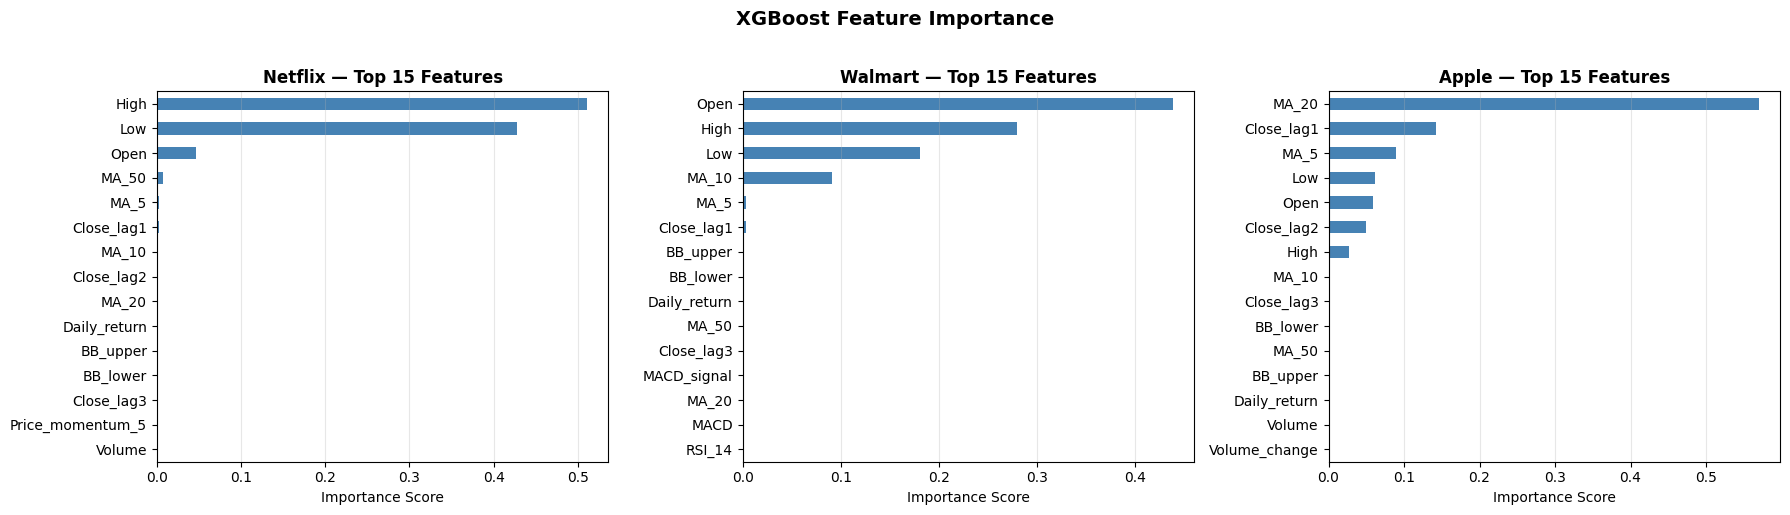

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, TICKERS):
    model = xgb_results[name]['model']
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    importances.nlargest(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('XGBoost Feature Importance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Model 4 — LSTM

LSTM (Long Short-Term Memory) is a recurrent neural network that can capture **long-range temporal dependencies** in time series — something linear models and tree models cannot do.

LSTM — Netflix:   RMSE=18.4410  R²=0.2421  MAPE=15.69%
LSTM — Walmart:   RMSE=26.4900  R²=-0.6189  MAPE=22.75%
LSTM — Apple:   RMSE=43.2468  R²=-0.8129  MAPE=15.99%


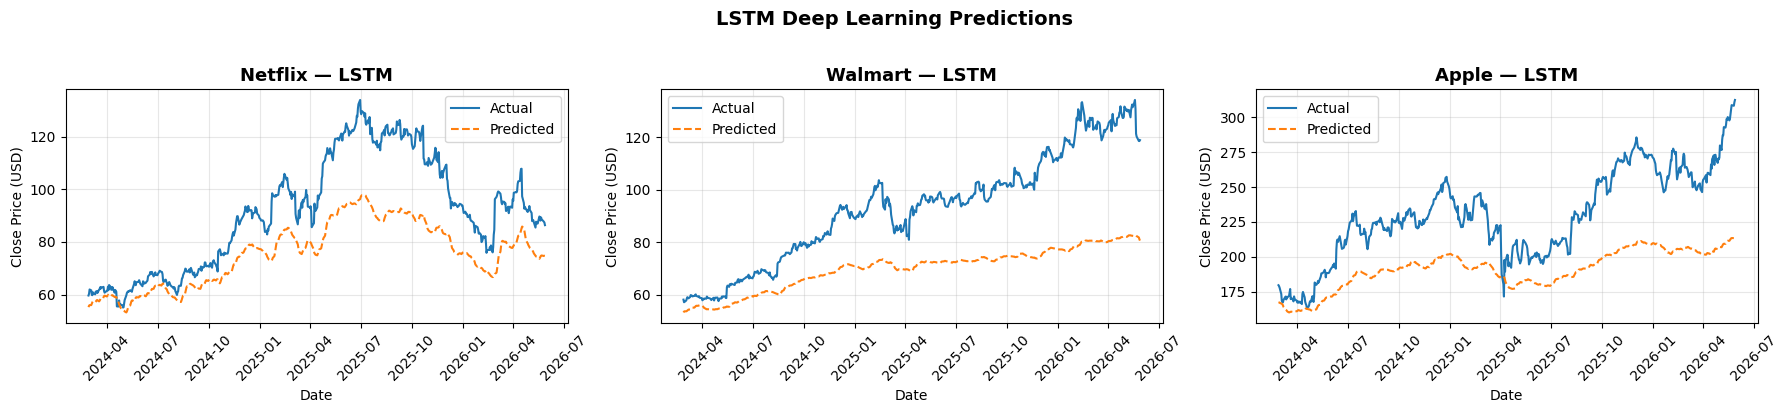

In [ ]:
LOOKBACK = 30   # use past 30 days to predict the next day

def build_lstm_sequences(df, features, target, lookback):
    """Reshape flat feature matrix into 3D (samples, timesteps, features) for LSTM."""
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_raw = scaler_X.fit_transform(df[features].values)
    y_raw = scaler_y.fit_transform(df[[target]].values)

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_raw)):
        X_seq.append(X_raw[i - lookback:i])
        y_seq.append(y_raw[i])

    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y


def build_lstm_model(n_features, lookback):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


lstm_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name in zip(axes, TICKERS):
    df_full = splits[name]['full'].reset_index(drop=True)
    split_idx = int(len(df_full) * 0.8)

    # Build sequences on full dataset so train/test boundary aligns properly
    X_all, y_all, sx, sy = build_lstm_sequences(df_full, FEATURES, TARGET, LOOKBACK)

    # Adjust split for lookback offset
    split_seq = split_idx - LOOKBACK

    X_tr, X_te = X_all[:split_seq], X_all[split_seq:]
    y_tr, y_te = y_all[:split_seq], y_all[split_seq:]

    model = build_lstm_model(len(FEATURES), LOOKBACK)
    es = EarlyStopping(patience=10, restore_best_weights=True)
    model.fit(X_tr, y_tr, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[es], verbose=0)

    y_pred_scaled = model.predict(X_te, verbose=0)
    y_pred  = sy.inverse_transform(y_pred_scaled).flatten()
    y_true  = sy.inverse_transform(y_te).flatten()

    # Dates for test window
    test_dates = df_full['Date'].iloc[split_idx:].values

    rmse, r2, mape = evaluate(y_true, y_pred)
    lstm_results[name] = {'model': model, 'scaler_y': sy, 'scaler_X': sx,
                           'y_test': y_true, 'y_pred': y_pred,
                           'rmse': rmse, 'r2': r2, 'mape': mape}
    print(f"LSTM — {name}:", end=" ")
    evaluate(y_true, y_pred, label=name)
    plot_predictions(test_dates, y_true, y_pred, name, 'LSTM', ax)

plt.suptitle('LSTM Deep Learning Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Model Comparison Dashboard


===== Model Comparison Table =====


,Stock,Model,RMSE,R²,MAPE (%)
0,Apple,Linear Regression,0.7845,0.9994,0.27
1,Apple,LSTM,43.2468,-0.8129,15.99
2,Apple,XGBoost (tuned),47.7396,-1.2091,15.43
3,Apple,KNN,83.5808,-5.7714,31.26
4,Netflix,Linear Regression,0.4301,0.9996,0.35
5,Netflix,LSTM,18.4410,0.2421,15.69
6,Netflix,XGBoost (tuned),31.1222,-1.1585,22.83
7,Netflix,KNN,53.3065,-5.3326,48.99
8,Walmart,Linear Regression,0.3968,0.9996,0.29
9,Walmart,LSTM,26.4900,-0.6189,22.75


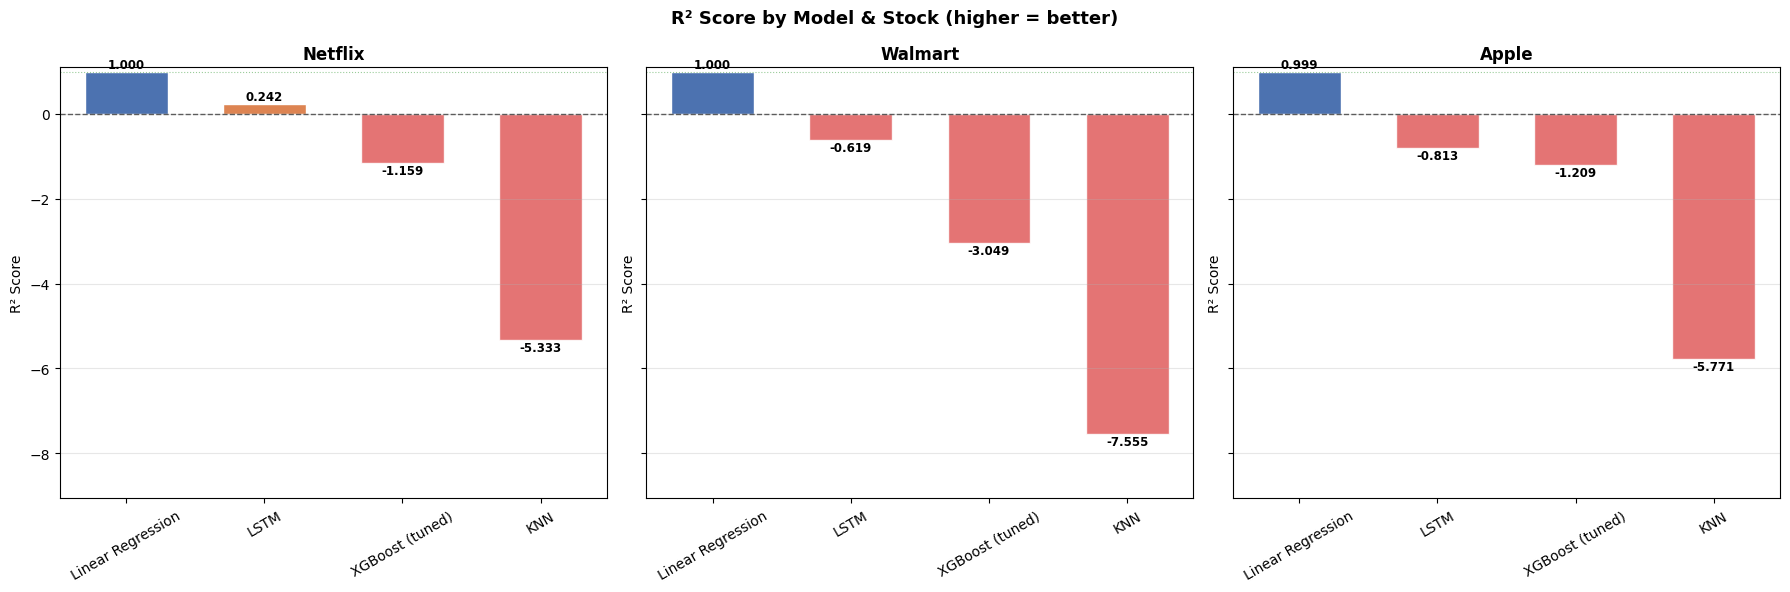

In [ ]:
rows = []
for name in TICKERS:
    for model_label, res in [('KNN', knn_results), ('Linear Regression', lr_results),
                               ('XGBoost (tuned)', xgb_results), ('LSTM', lstm_results)]:
        rows.append({
            'Stock': name,
            'Model': model_label,
            'RMSE':  round(res[name]['rmse'], 4),
            'R²':    round(res[name]['r2'],   4),
            'MAPE (%)': round(res[name]['mape'], 2)
        })

comparison_df = pd.DataFrame(rows).sort_values(['Stock', 'RMSE'])
print("\n===== Model Comparison Table =====")
display(comparison_df.reset_index(drop=True))

# --- Bar chart — R² by model per stock ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Compute shared y-axis limits with padding
all_r2 = comparison_df['R²']
y_min = min(all_r2.min() * 1.2, -0.1)  # add 20% headroom below
y_max = 1.1

for ax, name in zip(axes, TICKERS):
    sub = comparison_df[comparison_df['Stock'] == name]
    bars = ax.bar(sub['Model'], sub['R²'], color=colors, edgecolor='white', width=0.6)

    # Dynamic y-axis so negatives are always visible
    ax.set_ylim(y_min, y_max)

    # Reference line at 0 and at 1
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
    ax.axhline(1, color='green', linewidth=0.8, linestyle=':', alpha=0.4)

    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('R² Score')
    ax.tick_params(axis='x', rotation=30)

    # Label placement: above bar if positive, below bar if negative
    for bar in bars:
        h = bar.get_height()
        va = 'bottom' if h >= 0 else 'top'
        offset = 0.02 if h >= 0 else -0.02
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + offset,
            f'{h:.3f}',
            ha='center', va=va, fontsize=8.5, fontweight='bold',
            color='black'
        )

    # Color the negative bars differently for instant visual cue
    for bar, (_, row) in zip(bars, sub.iterrows()):
        if row['R²'] < 0:
            bar.set_facecolor('#E05C5C')  # red for bad models
            bar.set_alpha(0.85)

    ax.grid(axis='y', alpha=0.3)

plt.suptitle('R² Score by Model & Stock (higher = better)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. 30-Day Future Forecast

We use the **best-performing model per stock** (highest R²) to forecast the next 30 trading days.

Netflix: best model = Linear Regression (R²=0.9996)

Netflix — Next 30 trading days:


,Date,Predicted_Close
0,2026-05-29,86.45
1,2026-06-01,86.73
2,2026-06-02,86.91
3,2026-06-03,87.00
4,2026-06-04,86.92
5,2026-06-05,86.88
6,2026-06-08,86.88
7,2026-06-09,86.90
8,2026-06-10,86.90
9,2026-06-11,86.90


Walmart: best model = Linear Regression (R²=0.9996)

Walmart — Next 30 trading days:


,Date,Predicted_Close
0,2026-05-29,118.27
1,2026-06-01,118.47
2,2026-06-02,118.53
3,2026-06-03,118.55
4,2026-06-04,118.51
5,2026-06-05,118.50
6,2026-06-08,118.50
7,2026-06-09,118.51
8,2026-06-10,118.51
9,2026-06-11,118.51


Apple: best model = Linear Regression (R²=0.9994)

Apple — Next 30 trading days:


,Date,Predicted_Close
0,2026-05-29,311.85
1,2026-06-01,311.28
2,2026-06-02,310.69
3,2026-06-03,310.71
4,2026-06-04,310.93
5,2026-06-05,311.01
6,2026-06-08,310.95
7,2026-06-09,310.90
8,2026-06-10,310.90
9,2026-06-11,310.92


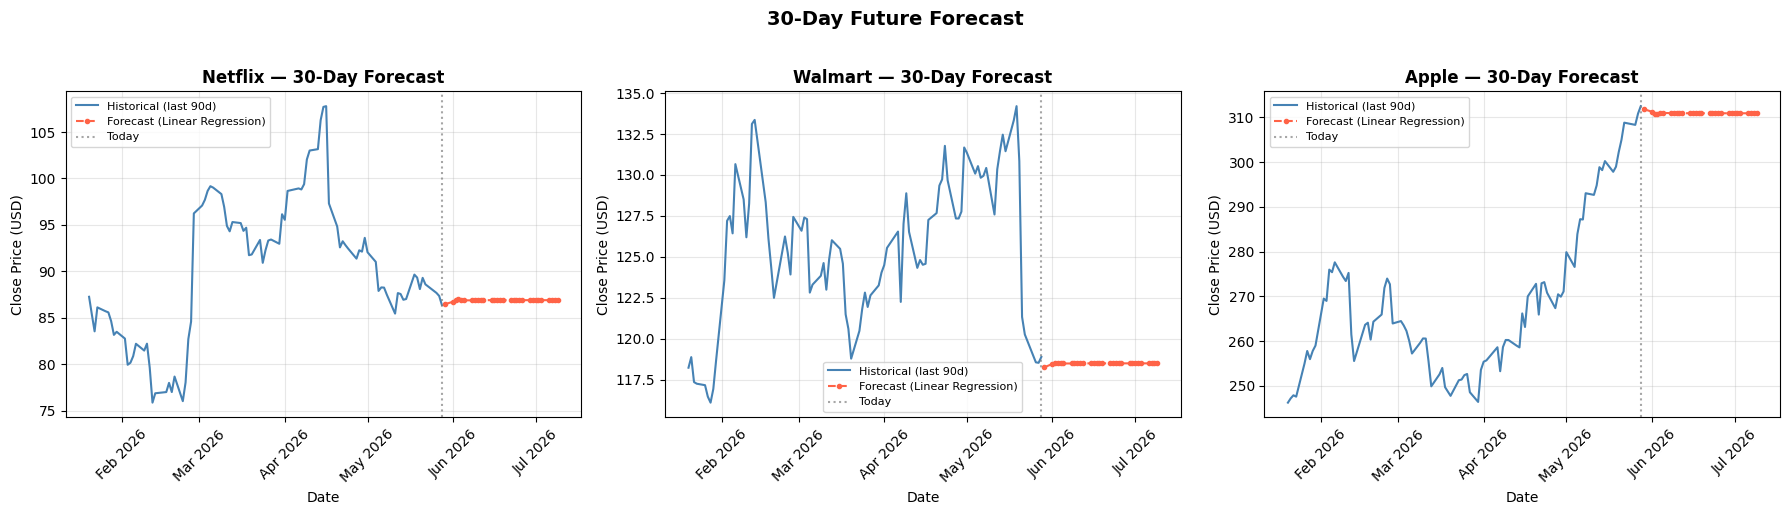

In [ ]:
FORECAST_DAYS = 30

def forecast_sklearn(model, last_known_row, n_days, features):
    """Iterative forecast using an sklearn model."""
    predictions = []
    current = last_known_row[features].copy()

    for _ in range(n_days):
        pred = model.predict(current.values.reshape(1, -1))[0]
        predictions.append(pred)
        # Shift lag features
        current['Close_lag3'] = current['Close_lag2']
        current['Close_lag2'] = current['Close_lag1']
        current['Close_lag1'] = pred
    return predictions


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, TICKERS):
    df_full  = splits[name]['full'].reset_index(drop=True)
    last_row = df_full.iloc[-1]
    last_date = last_row['Date']

    # Pick best model by R²
    candidates = {
        'KNN':              knn_results[name],
        'Linear Regression': lr_results[name],
        'XGBoost (tuned)':  xgb_results[name],
        'LSTM':             lstm_results[name]
    }
    best_label = max(candidates, key=lambda k: candidates[k]['r2'])
    print(f"{name}: best model = {best_label} (R²={candidates[best_label]['r2']:.4f})")

    # For LSTM, use a simpler iterative approach via the XGBoost model as fallback
    # (LSTM requires full sequence — using XGBoost for iterative forecast)
    if best_label == 'LSTM':
        forecast_model = xgb_results[name]['model']
        forecast_label = 'XGBoost (LSTM best on test; XGB used for iterative forecast)'
    else:
        forecast_model = candidates[best_label]['model']
        forecast_label = best_label

    future_preds = forecast_sklearn(forecast_model, last_row, FORECAST_DAYS, FEATURES)

    # Build future dates (business days only)
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

    # Plot: last 90 days of actuals + forecast
    history = df_full.tail(90)
    ax.plot(history['Date'], history['Close'], label='Historical (last 90d)', color='steelblue')
    ax.plot(future_dates, future_preds, label=f'Forecast ({forecast_label})',
            color='tomato', linestyle='--', marker='o', markersize=3)
    ax.axvline(last_date, color='gray', linestyle=':', alpha=0.7, label='Today')
    ax.set_title(f'{name} — {FORECAST_DAYS}-Day Forecast', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Print table
    fdf = pd.DataFrame({'Date': future_dates.date, 'Predicted_Close': np.round(future_preds, 2)})
    print(f"\n{name} — Next {FORECAST_DAYS} trading days:")
    display(fdf)

plt.suptitle(f'{FORECAST_DAYS}-Day Future Forecast', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Correlation Heatmap — Features vs Close Price

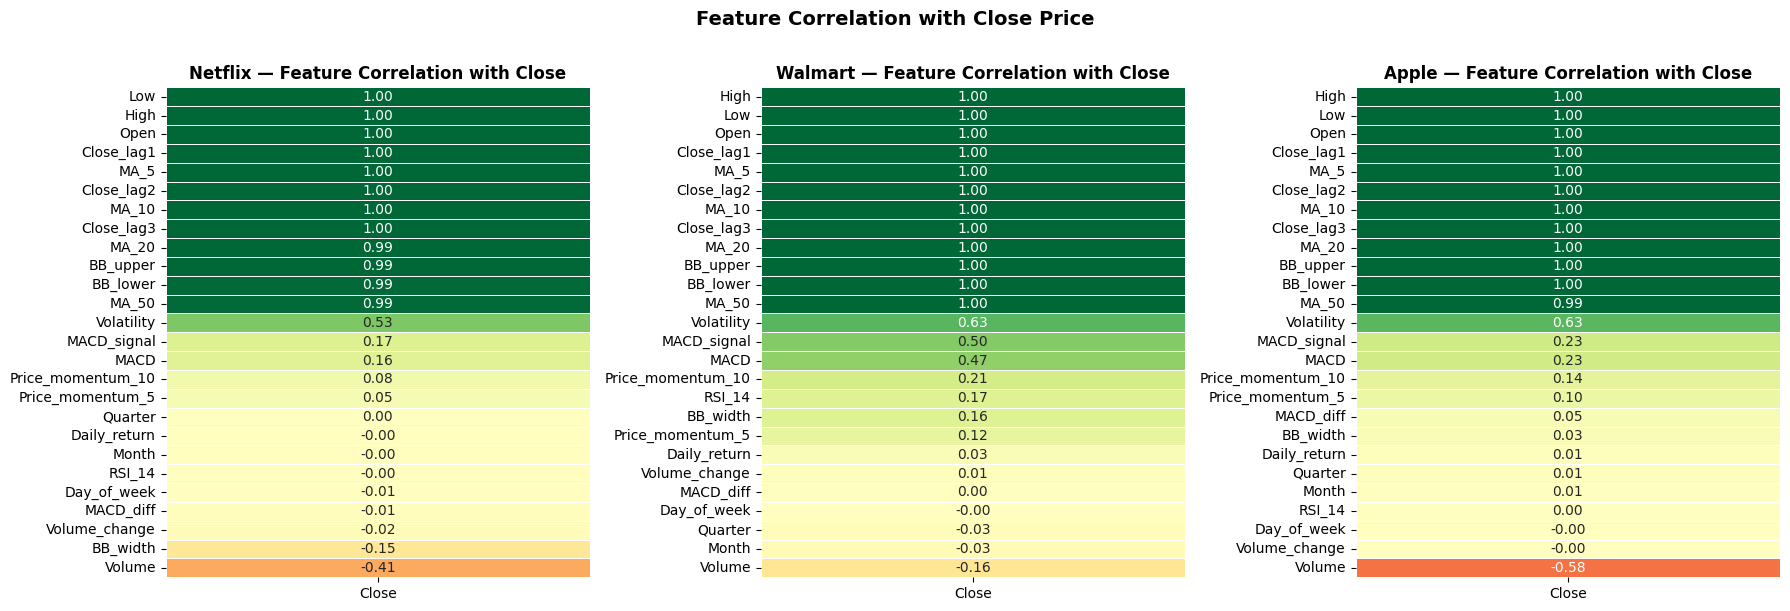

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, name in zip(axes, TICKERS):
    df_full = splits[name]['full']
    cols_to_corr = FEATURES + ['Close']
    corr = df_full[cols_to_corr].corr()[['Close']].drop('Close').sort_values('Close', ascending=False)
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=-1, vmax=1, linewidths=0.5, cbar=False)
    ax.set_title(f'{name} — Feature Correlation with Close', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Feature Correlation with Close Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

| Upgrade | Details |
|---|---|
| Real-time data | `yfinance` — fetches live data from Yahoo Finance, no API key needed |
| Technical indicators | RSI-14, MACD, Bollinger Bands (width + upper/lower) |
| Momentum features | 5-day & 10-day price momentum, daily return, volume change |
| Calendar features | Day of week, month, quarter |
| Extended MAs | MA-20 and MA-50 added |
| XGBoost tuning | GridSearchCV across estimators, depth, learning rate, subsample |
| LSTM model | 2-layer LSTM with Dropout + EarlyStopping |
| Metric: MAPE | Mean Absolute Percentage Error added for interpretability |
| 30-day forecast | Up from 5 days; best model per stock auto-selected |
| Feature importance | XGBoost top-15 features visualised per stock |
| Correlation heatmap | Shows which features matter most for each stock |